In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
df = pd.read_csv('insurance.csv')
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nСтатистика по числовым признакам:")
print(df.describe())

Размер датасета: (1338, 7)

Первые 5 строк:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None

Статистика по числовым признакам:
     

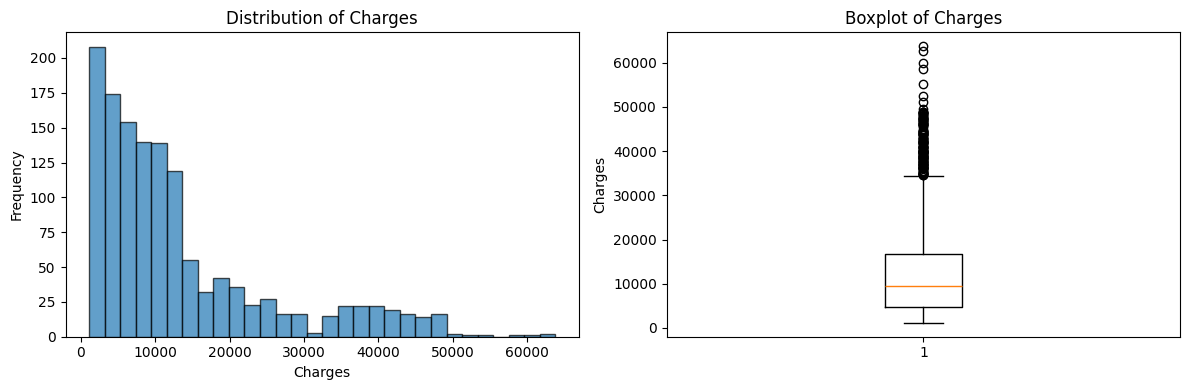

33-й перцентиль: 6196.93
66-й перцентиль: 12633.38

Распределение классов:
charges_category
0    442
1    441
2    455
Name: count, dtype: int64


In [5]:
# Преобразуем задачу регрессии в классификацию
# Разделим charges на 3 категории: низкие, средние, высокие расходы

# Анализ распределения charges
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['charges'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Charges')

plt.subplot(1, 2, 2)
plt.boxplot(df['charges'])
plt.ylabel('Charges')
plt.title('Boxplot of Charges')

plt.tight_layout()
plt.show()

# Определим квантили для разделения на классы
q33 = df['charges'].quantile(0.33)
q66 = df['charges'].quantile(0.66)
print(f"33-й перцентиль: {q33:.2f}")
print(f"66-й перцентиль: {q66:.2f}")

# Создаем целевую переменную для классификации
def categorize_charges(charge):
    if charge <= q33:
        return 0  # Низкие расходы
    elif charge <= q66:
        return 1  # Средние расходы
    else:
        return 2  # Высокие расходы

df['charges_category'] = df['charges'].apply(categorize_charges)
print("\nРаспределение классов:")
print(df['charges_category'].value_counts().sort_index())

In [6]:
# Предобработка данных
# Кодируем категориальные признаки
df_processed = df.copy()

# Label encoding для бинарных признаков
le_sex = LabelEncoder()
df_processed['sex_encoded'] = le_sex.fit_transform(df_processed['sex'])

le_smoker = LabelEncoder()
df_processed['smoker_encoded'] = le_smoker.fit_transform(df_processed['smoker'])

# One-hot encoding для региона
df_region = pd.get_dummies(df_processed['region'], prefix='region')
df_processed = pd.concat([df_processed, df_region], axis=1)

# Выбираем признаки для модели
feature_columns = ['age', 'sex_encoded', 'bmi', 'children', 'smoker_encoded', 
                   'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
X = df_processed[feature_columns].values
y = df_processed['charges_category'].values

print("Признаки:", feature_columns)
print("Размерность X:", X.shape)
print("Размерность y:", y.shape)

Признаки: ['age', 'sex_encoded', 'bmi', 'children', 'smoker_encoded', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
Размерность X: (1338, 9)
Размерность y: (1338,)


In [7]:
# Разделение данных на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")

# Стандартизация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразование в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

print(f"\nТензоры созданы:")
print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"y_train_tensor: {y_train_tensor.shape}")

Обучающая выборка: 1070 образцов
Тестовая выборка: 268 образцов

Тензоры созданы:
X_train_tensor: torch.Size([1070, 9])
y_train_tensor: torch.Size([1070])


In [8]:
# Создание класса нейронной сети
class InsuranceClassifier(nn.Module):
    def __init__(self, input_size=9, hidden_size=64, num_classes=3):
        super(InsuranceClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Инициализация модели
model = InsuranceClassifier(input_size=9, hidden_size=64, num_classes=3)
print("Архитектура модели:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nВсего параметров: {total_params}")

# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Архитектура модели:
InsuranceClassifier(
  (fc1): Linear(in_features=9, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)

Всего параметров: 835


In [9]:
# Цикл обучения
num_epochs = 100
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print("Начало обучения...")
print("-" * 60)

for epoch in range(num_epochs):
    # Обучение
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # Точность на обучении
    _, predicted = torch.max(outputs.data, 1)
    train_accuracy = (predicted == y_train_tensor).sum().item() / y_train_tensor.size(0)
    
    train_losses.append(loss.item())
    train_accuracies.append(train_accuracy)
    
    # Тестирование
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)
        _, test_predicted = torch.max(test_outputs.data, 1)
        test_accuracy = (test_predicted == y_test_tensor).sum().item() / y_test_tensor.size(0)
        
        test_losses.append(test_loss.item())
        test_accuracies.append(test_accuracy)
    
    if (epoch + 1) % 10 == 0:
        print(f"Эпоха [{epoch+1}/{num_epochs}], "
              f"Train Loss: {loss.item():.4f}, Train Acc: {train_accuracy:.4f}, "
              f"Test Loss: {test_loss.item():.4f}, Test Acc: {test_accuracy:.4f}")

print("-" * 60)
print("Обучение завершено!")

Начало обучения...
------------------------------------------------------------
Эпоха [10/100], Train Loss: 1.0383, Train Acc: 0.5374, Test Loss: 1.0193, Test Acc: 0.5896
Эпоха [20/100], Train Loss: 0.9687, Train Acc: 0.6551, Test Loss: 0.9487, Test Acc: 0.7090
Эпоха [30/100], Train Loss: 0.9061, Train Acc: 0.6991, Test Loss: 0.8847, Test Acc: 0.7388
Эпоха [40/100], Train Loss: 0.8483, Train Acc: 0.7654, Test Loss: 0.8256, Test Acc: 0.8134
Эпоха [50/100], Train Loss: 0.7943, Train Acc: 0.7897, Test Loss: 0.7704, Test Acc: 0.8284
Эпоха [60/100], Train Loss: 0.7441, Train Acc: 0.8000, Test Loss: 0.7196, Test Acc: 0.8358
Эпоха [70/100], Train Loss: 0.6983, Train Acc: 0.8121, Test Loss: 0.6737, Test Acc: 0.8433
Эпоха [80/100], Train Loss: 0.6573, Train Acc: 0.8206, Test Loss: 0.6330, Test Acc: 0.8433
Эпоха [90/100], Train Loss: 0.6213, Train Acc: 0.8271, Test Loss: 0.5978, Test Acc: 0.8433
Эпоха [100/100], Train Loss: 0.5905, Train Acc: 0.8336, Test Loss: 0.5675, Test Acc: 0.8433
---------

РЕЗУЛЬТАТЫ НЕЙРОННОЙ СЕТИ

Обучающая выборка:
  Accuracy: 0.8336
  F1-score: 0.8277

Тестовая выборка:
  Accuracy: 0.8433
  F1-score: 0.8378


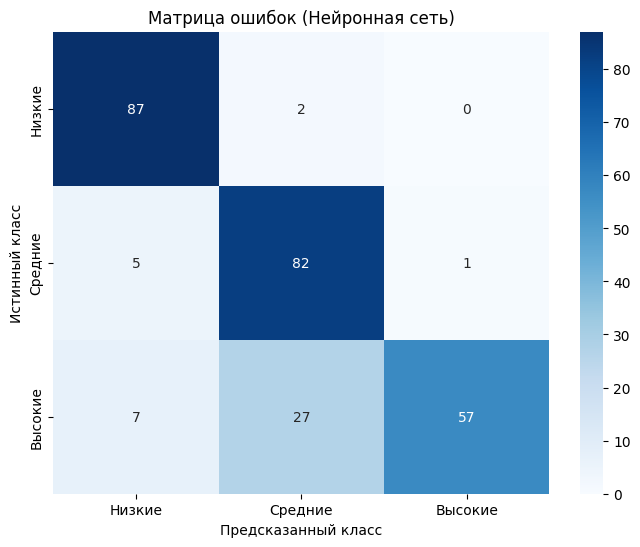

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# Финальные предсказания
model.eval()
with torch.no_grad():
    train_outputs = model(X_train_tensor)
    _, train_pred = torch.max(train_outputs, 1)
    train_pred = train_pred.numpy()
    
    test_outputs = model(X_test_tensor)
    _, test_pred = torch.max(test_outputs, 1)
    test_pred = test_pred.numpy()

# Метрики
train_accuracy = accuracy_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred, average='weighted')
test_accuracy = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average='weighted')

print("=" * 60)
print("РЕЗУЛЬТАТЫ НЕЙРОННОЙ СЕТИ")
print("=" * 60)
print(f"\nОбучающая выборка:")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  F1-score: {train_f1:.4f}")
print(f"\nТестовая выборка:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1-score: {test_f1:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Низкие', 'Средние', 'Высокие'],
            yticklabels=['Низкие', 'Средние', 'Высокие'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (Нейронная сеть)')
plt.show()

СРАВНЕНИЕ МОДЕЛЕЙ
                  Модель  Test Accuracy  Test F1
 Логистическая регрессия       0.861940 0.856896
           Случайный лес       0.906716 0.906195
       Gradient Boosting       0.921642 0.920507
               KNN (k=5)       0.865672 0.864145
          Дерево решений       0.880597 0.880680
Нейронная сеть (PyTorch)       0.843284 0.837758


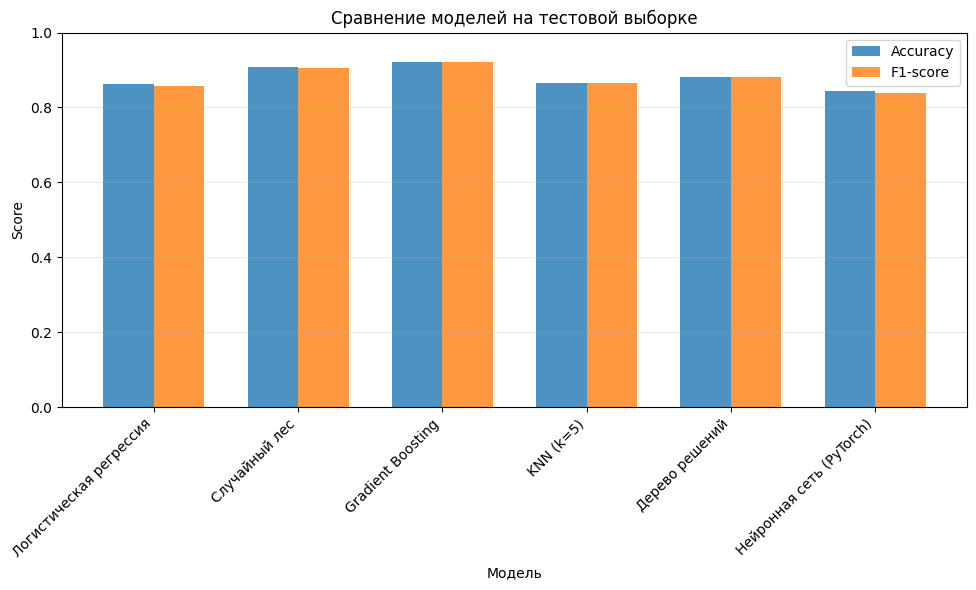

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

results = {
    'Модель': [],
    'Test Accuracy': [],
    'Test F1': []
}

# Логистическая регрессия
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
results['Модель'].append('Логистическая регрессия')
results['Test Accuracy'].append(accuracy_score(y_test, lr_pred))
results['Test F1'].append(f1_score(y_test, lr_pred, average='weighted'))

# Случайный лес
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
results['Модель'].append('Случайный лес')
results['Test Accuracy'].append(accuracy_score(y_test, rf_pred))
results['Test F1'].append(f1_score(y_test, rf_pred, average='weighted'))

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_pred = gb.predict(X_test_scaled)
results['Модель'].append('Gradient Boosting')
results['Test Accuracy'].append(accuracy_score(y_test, gb_pred))
results['Test F1'].append(f1_score(y_test, gb_pred, average='weighted'))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
results['Модель'].append('KNN (k=5)')
results['Test Accuracy'].append(accuracy_score(y_test, knn_pred))
results['Test F1'].append(f1_score(y_test, knn_pred, average='weighted'))

# Дерево решений
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
results['Модель'].append('Дерево решений')
results['Test Accuracy'].append(accuracy_score(y_test, dt_pred))
results['Test F1'].append(f1_score(y_test, dt_pred, average='weighted'))

# Нейронная сеть
results['Модель'].append('Нейронная сеть (PyTorch)')
results['Test Accuracy'].append(test_accuracy)
results['Test F1'].append(test_f1)

# Таблица результатов
results_df = pd.DataFrame(results)
print("=" * 70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 70)
print(results_df.to_string(index=False))

# График сравнения
plt.figure(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Test Accuracy'], width, label='Accuracy', alpha=0.8)
plt.bar(x + width/2, results_df['Test F1'], width, label='F1-score', alpha=0.8)

plt.xlabel('Модель')
plt.ylabel('Score')
plt.title('Сравнение моделей на тестовой выборке')
plt.xticks(x, results_df['Модель'], rotation=45, ha='right')
plt.legend()
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()